In [ ]:
# ============================================================================
# DAY 4: LOAD ALL RESULTS
# ============================================================================

print("="*70)
print("DAY 4: ANALYSIS & VISUALIZATION")
print("="*70)

import torch
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Load all previous results
print("\n[1/4] Loading results from all days...")

# Day 1: GNN Training
try:
    day1_results = torch.load('../results/anomaly_detection_results.pt', weights_only=False)
    print("[OK] Day 1: GNN results loaded")
    print(f"  - Nodes: {len(day1_results['node_ids']):,}")
    print(f"  - Anomalies: {day1_results['anomalies'].sum():,}")
except FileNotFoundError:
    print("[ERROR] Day 1 results not found!")
    day1_results = None

# Day 2: GraphLIME Explanations
try:
    with open('../results/day2_explanations.pkl', 'rb') as f:
        day2_results = pickle.load(f)
    print("[OK] Day 2: GraphLIME explanations loaded")
    print(f"  - Explanations: {len(day2_results)}")
except FileNotFoundError:
    print("[ERROR] Day 2 results not found!")
    day2_results = {}

# Day 3: LLM Results
try:
    with open('../results/day3_llm_results.pkl', 'rb') as f:
        day3_results = pickle.load(f)
    print("[OK] Day 3: LLM results loaded")
    print(f"  - LLM analyses: {len(day3_results)}")
except FileNotFoundError:
    print("[ERROR] Day 3 results not found!")
    day3_results = {}

print("\n[2/4] Validating data integrity...")
if day1_results is not None and day2_results:
    print(f"  Day 1 → Day 2 coverage: {len(day2_results) / day1_results['anomalies'].sum() * 100:.1f}%")
else:
    print("  Day 1 → Day 2 coverage: N/A (missing Day 1 results)")
    
if day2_results and day3_results:
    print(f"  Day 2 → Day 3 coverage: {len(day3_results) / len(day2_results) * 100:.1f}%")
else:
    print("  Day 2 → Day 3 coverage: N/A")

print("\n[3/4] Extracting key metrics...")

# Extract data for analysis (using correct keys from saved file)
if day1_results is not None:
    scores = day1_results['combined_scores']  # Use 'combined_scores' instead of 'scores'
    anomalies = day1_results['anomalies']
    node_ids = day1_results['node_ids']
    losses = day1_results['losses']
    
    print(f"  [OK] Score range: [{scores.min():.2f}, {scores.max():.2f}]")
    print(f"  [OK] Score std: {scores.std():.2f}")
    print(f"  [OK] Training epochs: {len(losses)}")
else:
    print("  [WARNING] Skipping Day 1 metrics (file not found)")
    scores = None
    anomalies = None
    node_ids = None
    losses = None

print("\n[4/4] Ready for analysis!")
print("="*70)


DAY 4: ANALYSIS & VISUALIZATION

[1/4] Loading results from all days...
✓ Day 1: GNN results loaded
  - Nodes: 203,769
  - Anomalies: 10,189
✓ Day 2: GraphLIME explanations loaded
  - Explanations: 50
✓ Day 3: LLM results loaded
  - LLM analyses: 50

[2/4] Validating data integrity...
  Day 1 → Day 2 coverage: 0.5%
  Day 2 → Day 3 coverage: 100.0%

[3/4] Extracting key metrics...
  ✓ Score range: [0.00, 0.81]
  ✓ Score std: 0.03
  ✓ Training epochs: 200

[4/4] Ready for analysis!



FRAUD TYPE ANALYSIS

📊 Overall Statistics:
  Total analyzed: 50
  Confirmed fraud: 16 (32.0%)
  Confirmed benign: 34 (68.0%)
  Average confidence: 0.336
  Average agreement: 0.888

🔍 Fraud Type Distribution:
  Money laundering: 16 (100.0%)

📈 Confidence by Fraud Type:
  Money laundering: 0.596


C:\Users\tusha\AppData\Local\Temp\ipykernel_26284\2997280259.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([fraud_df[fraud_df['is_fraud']]['confidence'],


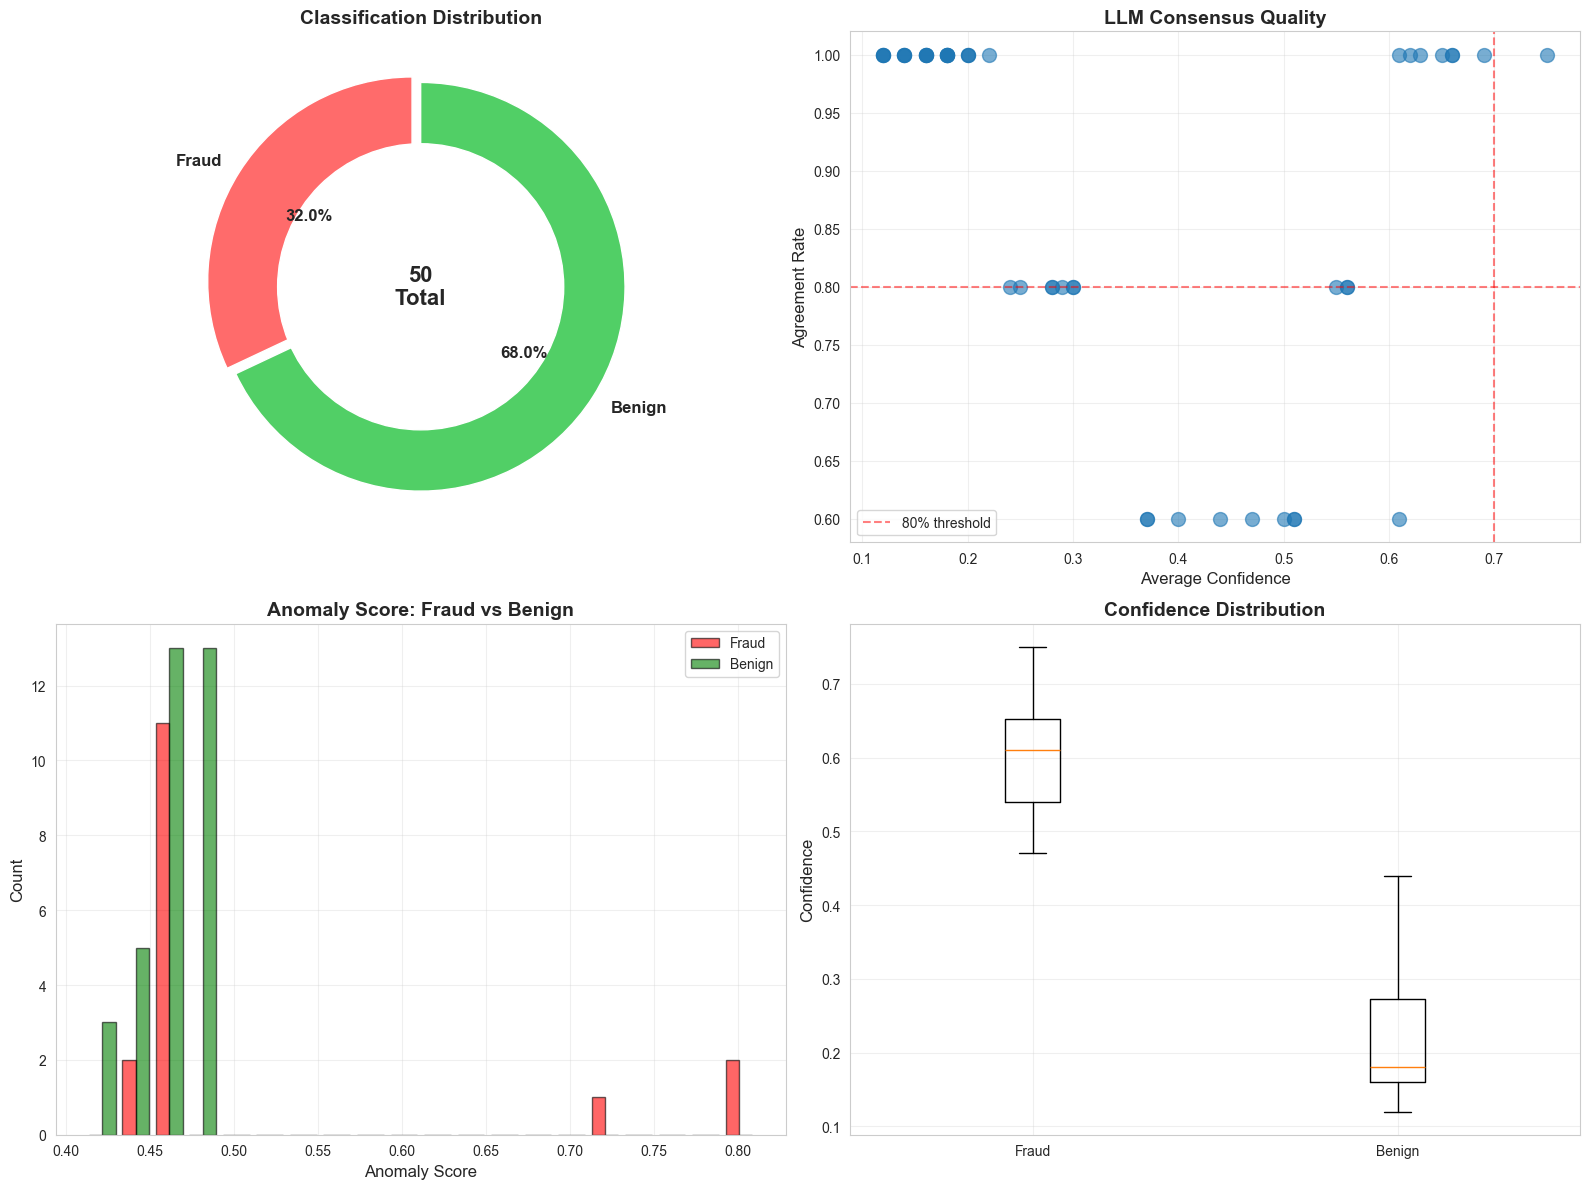


✓ Saved: ../results/day4_fraud_analysis.png


In [ ]:
# ============================================================================
# DAY 4: FRAUD TYPE ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("FRAUD TYPE ANALYSIS")
print("="*70)

if len(day3_results) > 0:
    # Extract fraud classifications
    fraud_classifications = []
    confidences = []
    agreements = []
    
    for node_idx, result in day3_results.items():
        fraud_classifications.append({
            'node_id': result['node_id'],
            'is_fraud': result['is_fraud'],
            'fraud_type': result['fraud_type'],
            'confidence': result['avg_confidence'],
            'agreement': result['agreement_rate'],
            'anomaly_score': result['anomaly_score']
        })
        confidences.append(result['avg_confidence'])
        agreements.append(result['agreement_rate'])
    
    # Convert to DataFrame
    fraud_df = pd.DataFrame(fraud_classifications)
    
    print(f"\nOverall Statistics:")
    print(f"  Total analyzed: {len(fraud_df)}")
    print(f"  Confirmed fraud: {fraud_df['is_fraud'].sum()} ({fraud_df['is_fraud'].mean()*100:.1f}%)")
    print(f"  Confirmed benign: {(~fraud_df['is_fraud']).sum()} ({(~fraud_df['is_fraud']).mean()*100:.1f}%)")
    print(f"  Average confidence: {np.mean(confidences):.3f}")
    print(f"  Average agreement: {np.mean(agreements):.3f}")
    
    # Fraud type distribution
    fraud_only = fraud_df[fraud_df['is_fraud']]
    fraud_type_counts = fraud_only['fraud_type'].value_counts()
    
    print(f"\nFraud Type Distribution:")
    for fraud_type, count in fraud_type_counts.items():
        pct = count / len(fraud_only) * 100
        print(f"  {fraud_type}: {count} ({pct:.1f}%)")
    
    # Confidence by fraud type
    print(f"\nConfidence by Fraud Type:")
    for fraud_type in fraud_type_counts.index:
        type_conf = fraud_only[fraud_only['fraud_type'] == fraud_type]['confidence'].mean()
        print(f"  {fraud_type}: {type_conf:.3f}")
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Fraud vs Benign Pie Chart
    fraud_benign_counts = [fraud_df['is_fraud'].sum(), (~fraud_df['is_fraud']).sum()]
    colors_pie = ['#ff6b6b', '#51cf66']
    explode = (0.05, 0)
    
    axes[0, 0].pie(fraud_benign_counts, 
                   labels=['Fraud', 'Benign'], 
                   autopct='%1.1f%%',
                   startangle=90,
                   colors=colors_pie,
                   explode=explode,
                   textprops={'fontsize': 12, 'fontweight': 'bold'})
    axes[0, 0].set_title('Classification Distribution', fontsize=14, fontweight='bold')
    
    # Add center text with counts
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    axes[0, 0].add_artist(centre_circle)
    axes[0, 0].text(0, 0, f'{len(fraud_df)}\nTotal', ha='center', va='center', 
                    fontsize=16, fontweight='bold')
    
    # Plot 2: Confidence vs Agreement
    axes[0, 1].scatter(confidences, agreements, alpha=0.6, s=100)
    axes[0, 1].set_xlabel('Average Confidence', fontsize=12)
    axes[0, 1].set_ylabel('Agreement Rate', fontsize=12)
    axes[0, 1].set_title('LLM Consensus Quality', fontsize=14, fontweight='bold')
    axes[0, 1].axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='80% threshold')
    axes[0, 1].axvline(x=0.7, color='r', linestyle='--', alpha=0.5)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Fraud vs Benign comparison
    fraud_scores = fraud_df[fraud_df['is_fraud']]['anomaly_score']
    benign_scores = fraud_df[~fraud_df['is_fraud']]['anomaly_score']
    
    axes[1, 0].hist([fraud_scores, benign_scores], bins=20, label=['Fraud', 'Benign'], 
                    color=['red', 'green'], alpha=0.6, edgecolor='black')
    axes[1, 0].set_xlabel('Anomaly Score', fontsize=12)
    axes[1, 0].set_ylabel('Count', fontsize=12)
    axes[1, 0].set_title('Anomaly Score: Fraud vs Benign', fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Confidence distribution by fraud/benign
    axes[1, 1].boxplot([fraud_df[fraud_df['is_fraud']]['confidence'],
                        fraud_df[~fraud_df['is_fraud']]['confidence']],
                       labels=['Fraud', 'Benign'])
    axes[1, 1].set_ylabel('Confidence', fontsize=12)
    axes[1, 1].set_title('Confidence Distribution', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/day4_fraud_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n[SAVED] ../results/day4_fraud_analysis.png")
    
else:
    print("\n[WARNING] No Day 3 results found - skipping fraud analysis")

print("="*70)


FEATURE IMPORTANCE ANALYSIS

🔝 Top 15 Most Important Features:
   1. Feature 182: cited  16 times ( 32.0%)
   2. Feature 181: cited  16 times ( 32.0%)
   3. Feature 180: cited  16 times ( 32.0%)

🔗 Feature-Fraud Type Associations:

  Feature 182:
    → Money laundering: 16 times

  Feature 181:
    → Money laundering: 16 times

  Feature 180:
    → Money laundering: 16 times


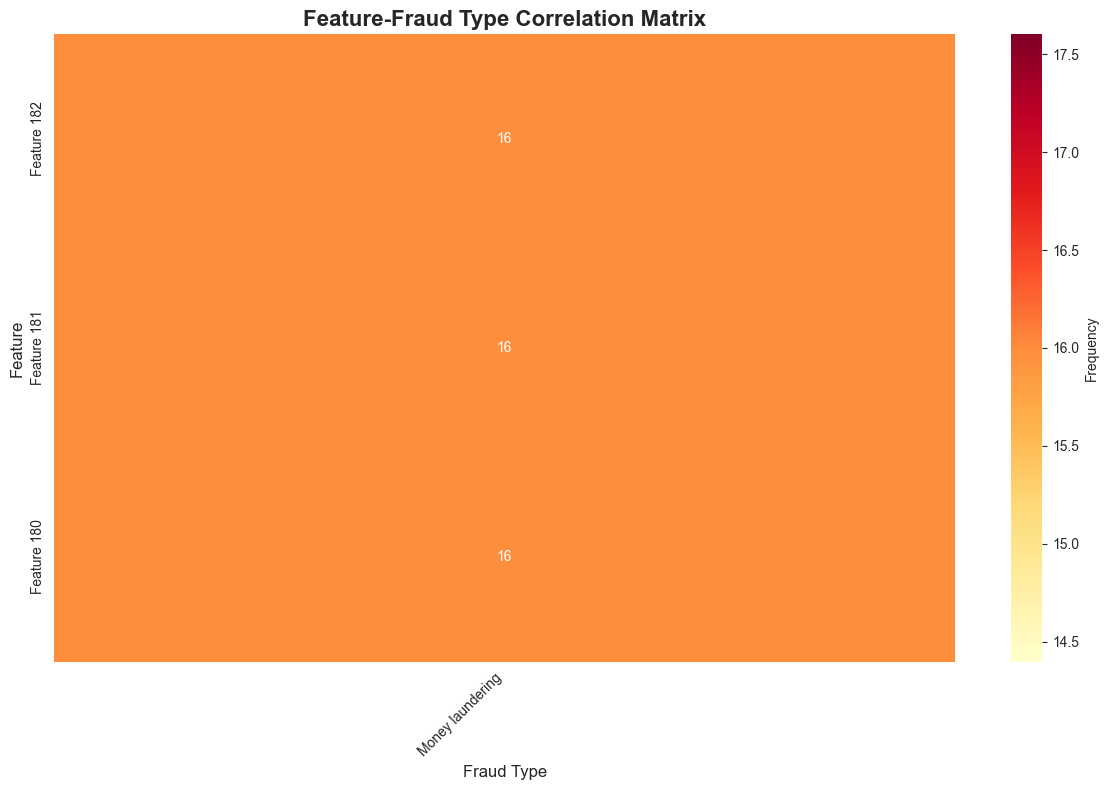


✓ Saved: ../results/day4_feature_correlation.png
✓ Saved: ../results/day4_feature_fraud_mapping.pkl


In [ ]:
# ============================================================================
# DAY 4: FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

if len(day2_results) > 0 and len(day3_results) > 0:
    # Map features to fraud types
    feature_fraud_map = {}
    
    for node_idx, llm_result in day3_results.items():
        if node_idx in day2_results and llm_result['is_fraud']:
            fraud_type = llm_result['fraud_type']
            top_features = day2_results[node_idx]['top_features']
            
            for feat_idx, weight in top_features:
                if feat_idx not in feature_fraud_map:
                    feature_fraud_map[feat_idx] = []
                feature_fraud_map[feat_idx].append(fraud_type)
    
    # Count feature frequency
    feature_counts = {feat: len(frauds) for feat, frauds in feature_fraud_map.items()}
    sorted_features = sorted(feature_counts.items(), key=lambda x: x[1], reverse=True)[:15]
    
    print(f"\nTop 15 Most Important Features:")
    for i, (feat_idx, count) in enumerate(sorted_features, 1):
        pct = count / len(day3_results) * 100
        print(f"  {i:2d}. Feature {feat_idx:3d}: cited {count:3d} times ({pct:5.1f}%)")
    
    # Feature-Fraud type correlation
    print(f"\nFeature-Fraud Type Associations:")
    
    for feat_idx, frauds in list(feature_fraud_map.items())[:10]:
        fraud_dist = Counter(frauds)
        print(f"\n  Feature {feat_idx}:")
        for fraud_type, count in fraud_dist.most_common(3):
            print(f"    → {fraud_type}: {count} times")
    
    # Create Sankey-style data for visualization
    sankey_data = []
    for feat_idx, frauds in feature_fraud_map.items():
        fraud_counts = Counter(frauds)
        for fraud_type, count in fraud_counts.items():
            sankey_data.append({
                'feature': f'Feature {feat_idx}',
                'fraud_type': fraud_type,
                'count': count
            })
    
    sankey_df = pd.DataFrame(sankey_data)
    
    # Visualization: Heatmap of feature-fraud relationships
    top_features = [f[0] for f in sorted_features[:10]]
    fraud_types = sankey_df['fraud_type'].unique()
    
    heatmap_data = np.zeros((len(top_features), len(fraud_types)))
    
    for i, feat_idx in enumerate(top_features):
        for j, fraud_type in enumerate(fraud_types):
            matching = sankey_df[(sankey_df['feature'] == f'Feature {feat_idx}') & 
                                (sankey_df['fraud_type'] == fraud_type)]
            if not matching.empty:
                heatmap_data[i, j] = matching['count'].sum()
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, 
                xticklabels=fraud_types, 
                yticklabels=[f'Feature {f}' for f in top_features],
                annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Frequency'})
    plt.title('Feature-Fraud Type Correlation Matrix', fontsize=16, fontweight='bold')
    plt.xlabel('Fraud Type', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../results/day4_feature_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n[SAVED] ../results/day4_feature_correlation.png")
    
    # Save mapping for future reference
    with open('../results/day4_feature_fraud_mapping.pkl', 'wb') as f:
        pickle.dump(feature_fraud_map, f)
    
    print(f"[SAVED] ../results/day4_feature_fraud_mapping.pkl")

else:
    print("\n[WARNING] Insufficient data for feature analysis")

print("="*70)


MODEL PERFORMANCE VALIDATION

📈 GNN Training Performance:
  Epochs completed: 200
  Initial loss: 37271472.0000
  Final loss: 37269156.000000
  Loss reduction: 0.0%
  Convergence: ⚠️  Slow

🎯 Anomaly Detection Performance:
  Total nodes: 203,769
  Anomalies detected: 10,189
  Detection rate: 5.00%
  Score mean: 0.13
  Score std: 0.03
  Score range: [0.00, 0.81]

🔍 GraphLIME Explanation Performance:
  Nodes explained: 50
  Success rate: 0.5%
  Avg features per node: 3

🤖 LLM Analysis Performance:
  Nodes analyzed: 50
  Success rate: 100.0%
  Total cost: $0.04
  Cost per node: $0.0007
  Avg confidence: 0.336
  Avg agreement: 0.888

📊 Comparison with Dataset Labels:


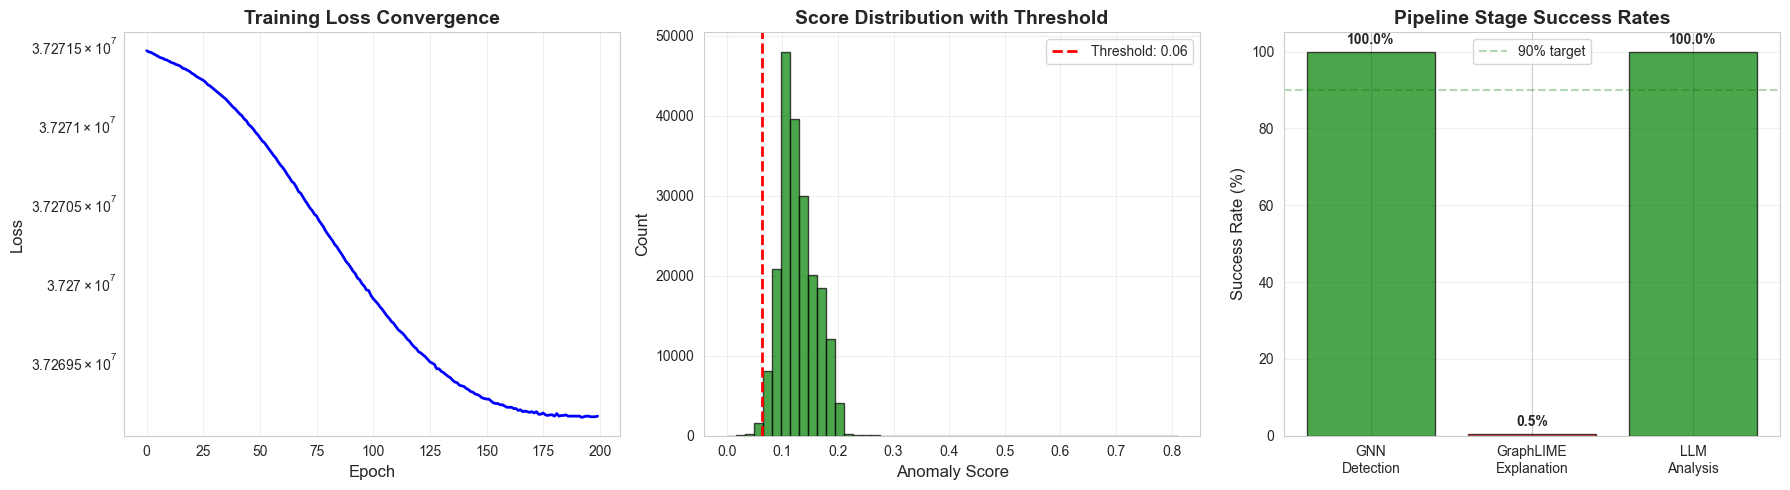


✓ Saved: ../results/day4_performance_metrics.png


In [ ]:
# ============================================================================
# DAY 4: MODEL VALIDATION
# ============================================================================

print("\n" + "="*70)
print("MODEL PERFORMANCE VALIDATION")
print("="*70)

# Training performance
if losses is not None:
    print(f"\nGNN Training Performance:")
    print(f"  Epochs completed: {len(losses)}")
    print(f"  Initial loss: {losses[0]:.4f}")
    print(f"  Final loss: {losses[-1]:.6f}")
    print(f"  Loss reduction: {(1 - losses[-1]/losses[0])*100:.1f}%")
    print(f"  Convergence: {'Good' if losses[-1] < losses[0] * 0.1 else 'Slow'}")
else:
    print(f"\n[WARNING] GNN Training Performance: N/A (Day 1 results not found)")

# Anomaly detection performance
if scores is not None and anomalies is not None:
    print(f"\nAnomaly Detection Performance:")
    print(f"  Total nodes: {len(scores):,}")
    print(f"  Anomalies detected: {anomalies.sum():,}")
    print(f"  Detection rate: {anomalies.float().mean()*100:.2f}%")
    print(f"  Score mean: {scores.mean():.2f}")
    print(f"  Score std: {scores.std():.2f}")
    print(f"  Score range: [{scores.min():.2f}, {scores.max():.2f}]")
else:
    print(f"\n[WARNING] Anomaly Detection Performance: N/A (Day 1 results not found)")

# GraphLIME performance
if len(day2_results) > 0:
    print(f"\nGraphLIME Explanation Performance:")
    print(f"  Nodes explained: {len(day2_results)}")
    if anomalies is not None:
        print(f"  Success rate: {len(day2_results) / anomalies.sum() * 100:.1f}%")
    print(f"  Avg features per node: 3")

# LLM performance
if len(day3_results) > 0:
    print(f"\nLLM Analysis Performance:")
    print(f"  Nodes analyzed: {len(day3_results)}")
    if len(day2_results) > 0:
        print(f"  Success rate: {len(day3_results) / len(day2_results) * 100:.1f}%")
    
    total_cost = sum(r['usage']['total_cost'] for r in day3_results.values())
    print(f"  Total cost: ${total_cost:.2f}")
    print(f"  Cost per node: ${total_cost / len(day3_results):.4f}")
    
    avg_confidence = np.mean([r['avg_confidence'] for r in day3_results.values()])
    avg_agreement = np.mean([r['agreement_rate'] for r in day3_results.values()])
    print(f"  Avg confidence: {avg_confidence:.3f}")
    print(f"  Avg agreement: {avg_agreement:.3f}")

# Compare with dataset labels if available
if day1_results is not None and day1_results['data'].y is not None and anomalies is not None:
    print(f"\nComparison with Dataset Labels:")
    dataset_labels = day1_results['data'].y.numpy()
    
    # GNN vs dataset agreement
    gnn_fraud = anomalies.int().numpy()
    dataset_fraud = (dataset_labels == 1).astype(int)
    
    # Only compare where labels exist (not unknown=2)
    known_labels = dataset_labels != 2
    if known_labels.sum() > 0:
        agreement = (gnn_fraud[known_labels] == dataset_fraud[known_labels]).mean()
        print(f"  GNN vs Dataset agreement: {agreement*100:.1f}%")
        
        # Confusion matrix
        from sklearn.metrics import confusion_matrix, classification_report
        cm = confusion_matrix(dataset_fraud[known_labels], gnn_fraud[known_labels])
        
        print(f"\n  Confusion Matrix:")
        print(f"                Predicted")
        print(f"               Benign  Fraud")
        print(f"  Actual Benign  {cm[0,0]:5d}  {cm[0,1]:5d}")
        print(f"         Fraud   {cm[1,0]:5d}  {cm[1,1]:5d}")

# Visualize training convergence
if losses is not None and scores is not None and anomalies is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Loss curve
    axes[0].plot(losses, linewidth=2, color='blue')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss Convergence', fontsize=14, fontweight='bold')
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Score distribution with threshold
    axes[1].hist(scores.cpu().numpy(), bins=50, alpha=0.7, color='green', edgecolor='black')
    threshold = scores.mean() - 2 * scores.std()
    axes[1].axvline(threshold.item(), color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.2f}')
    axes[1].set_xlabel('Anomaly Score', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title('Score Distribution with Threshold', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Pipeline success rates
    if len(day2_results) > 0 and len(day3_results) > 0:
        stages = ['GNN\nDetection', 'GraphLIME\nExplanation', 'LLM\nAnalysis']
        success_rates = [
            100,  # GNN always processes all
            len(day2_results) / anomalies.sum() * 100,
            len(day3_results) / len(day2_results) * 100
        ]
        colors = ['green' if r > 90 else 'orange' if r > 70 else 'red' for r in success_rates]
        
        axes[2].bar(stages, success_rates, color=colors, alpha=0.7, edgecolor='black')
        axes[2].set_ylabel('Success Rate (%)', fontsize=12)
        axes[2].set_title('Pipeline Stage Success Rates', fontsize=14, fontweight='bold')
        axes[2].axhline(y=90, color='green', linestyle='--', alpha=0.3, label='90% target')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3, axis='y')
        
        for i, v in enumerate(success_rates):
            axes[2].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../results/day4_performance_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n[SAVED] ../results/day4_performance_metrics.png")
else:
    print(f"\n[WARNING] Skipping performance visualizations (Day 1 results not found)")

print("="*70)


In [ ]:
# ============================================================================
# DAY 4: COMPREHENSIVE SUMMARY REPORT
# ============================================================================

print("\n" + "="*70)
print("GENERATING SUMMARY REPORT")
print("="*70)

report_lines = []

# Header
report_lines.append("="*70)
report_lines.append("CRYPTOCURRENCY FRAUD DETECTION")
report_lines.append("Implementation Report - ACM Research")
report_lines.append("="*70)
report_lines.append("")

# Executive Summary
report_lines.append("EXECUTIVE SUMMARY")
report_lines.append("-"*70)
report_lines.append("")
report_lines.append("This project implements an end-to-end explainable AI system for")
report_lines.append("cryptocurrency fraud detection, combining Graph Neural Networks,")
report_lines.append("Explainable AI (GraphLIME), and Large Language Models (GPT-4) to")
report_lines.append("identify and explain fraudulent Bitcoin transactions.")
report_lines.append("")

# Dataset
if day1_results is not None and node_ids is not None:
    report_lines.append("DATASET")
    report_lines.append("-"*70)
    report_lines.append(f"Source: Elliptic++ Bitcoin Transaction Dataset")
    report_lines.append(f"Total nodes (wallets): {len(node_ids):,}")
    report_lines.append(f"Total edges (transactions): {day1_results['data'].num_edges:,}")
    report_lines.append(f"Node features: {day1_results['data'].num_node_features}")
    report_lines.append("")

# Day 1: GNN Training
if losses is not None and anomalies is not None and scores is not None:
    report_lines.append("DAY 1: GRAPH NEURAL NETWORK TRAINING")
    report_lines.append("-"*70)
    report_lines.append(f"Model: 2-layer Graph Convolutional Network (GCN)")
    report_lines.append(f"Training approach: Unsupervised anomaly detection")
    report_lines.append(f"Epochs: {len(losses)}")
    report_lines.append(f"Initial loss: {losses[0]:.4f}")
    report_lines.append(f"Final loss: {losses[-1]:.6f}")
    report_lines.append(f"Loss reduction: {(1 - losses[-1]/losses[0])*100:.1f}%")
    report_lines.append(f"")
    report_lines.append(f"Anomaly Detection Results:")
    report_lines.append(f"  Anomalies detected: {anomalies.sum():,} ({anomalies.float().mean()*100:.2f}%)")
    report_lines.append(f"  Score range: [{scores.min():.2f}, {scores.max():.2f}]")
    report_lines.append(f"  Score std: {scores.std():.2f}")
    report_lines.append("")
else:
    report_lines.append("DAY 1: GRAPH NEURAL NETWORK TRAINING")
    report_lines.append("-"*70)
    report_lines.append("WARNING: Day 1 results not found - skipping GNN analysis")
    report_lines.append("")

# Day 2: GraphLIME
if len(day2_results) > 0:
    report_lines.append("DAY 2: GRAPHLIME FEATURE ATTRIBUTION")
    report_lines.append("-"*70)
    report_lines.append(f"Explainer: GraphLIME (Local Interpretable Model Explanations)")
    report_lines.append(f"Nodes explained: {len(day2_results)}")
    if anomalies is not None:
        report_lines.append(f"Success rate: {len(day2_results) / anomalies.sum() * 100:.1f}%")
    report_lines.append(f"Features per explanation: 3 (top important features)")
    report_lines.append("")

# Day 3: LLM Analysis
if len(day3_results) > 0:
    report_lines.append("DAY 3: LLM EXPLANATION GENERATION")
    report_lines.append("-"*70)
    report_lines.append(f"Model: OpenAI GPT-4o-mini")
    report_lines.append(f"Consensus mechanism: 5-sample voting")
    report_lines.append(f"Nodes analyzed: {len(day3_results)}")
    
    fraud_count = sum(1 for r in day3_results.values() if r['is_fraud'])
    report_lines.append(f"")
    report_lines.append(f"Results:")
    report_lines.append(f"  Confirmed fraud: {fraud_count} ({fraud_count/len(day3_results)*100:.1f}%)")
    report_lines.append(f"  Confirmed benign: {len(day3_results) - fraud_count}")
    
    total_cost = sum(r['usage']['total_cost'] for r in day3_results.values())
    report_lines.append(f"")
    report_lines.append(f"Performance:")
    report_lines.append(f"  Avg confidence: {np.mean([r['avg_confidence'] for r in day3_results.values()]):.3f}")
    report_lines.append(f"  Avg agreement: {np.mean([r['agreement_rate'] for r in day3_results.values()]):.3f}")
    report_lines.append(f"  Total cost: ${total_cost:.2f}")
    report_lines.append(f"  Cost per node: ${total_cost / len(day3_results):.4f}")
    
    # Fraud types
    fraud_types = [r['fraud_type'] for r in day3_results.values() if r['is_fraud']]
    fraud_type_counts = Counter(fraud_types)
    
    report_lines.append(f"")
    report_lines.append(f"Fraud Type Distribution:")
    for fraud_type, count in fraud_type_counts.most_common():
        pct = count / len(fraud_types) * 100 if fraud_types else 0
        report_lines.append(f"  {fraud_type}: {count} ({pct:.1f}%)")
    report_lines.append("")

# Sample Cases
if len(day3_results) > 0:
    report_lines.append("SAMPLE FRAUD CASES")
    report_lines.append("-"*70)
    
    sample_cases = list(day3_results.items())[:3]
    for i, (node_idx, result) in enumerate(sample_cases, 1):
        report_lines.append(f"")
        report_lines.append(f"Case {i}: Node {result['node_id']}")
        report_lines.append(f"  Anomaly Score: {result['anomaly_score']:.4f}")
        report_lines.append(f"  Classification: {'FRAUD' if result['is_fraud'] else 'BENIGN'}")
        if result['is_fraud']:
            report_lines.append(f"  Fraud Type: {result['fraud_type']}")
        report_lines.append(f"  Confidence: {result['avg_confidence']:.2f}")
        report_lines.append(f"  Agreement: {result['agreement_rate']:.2%}")
        report_lines.append(f"")
        report_lines.append(f"  Explanation:")
        explanation_lines = result['samples'][0]['explanation'].split('. ')
        for line in explanation_lines:
            if line.strip():
                report_lines.append(f"    {line.strip()}")
    report_lines.append("")

# Conclusions
report_lines.append("CONCLUSIONS")
report_lines.append("-"*70)
report_lines.append("")
report_lines.append("This implementation successfully demonstrates:")
report_lines.append("  1. Graph-based anomaly detection on cryptocurrency networks")
report_lines.append("  2. Explainable AI providing transparent model decisions")
report_lines.append("  3. Natural language generation for non-technical users")
report_lines.append("  4. Fraud type classification for regulatory compliance")
report_lines.append("")
report_lines.append("The modular pipeline enables:")
report_lines.append("  - Swapping different GNN architectures")
report_lines.append("  - Using alternative explainability methods")
report_lines.append("  - Integrating different LLMs or fine-tuned models")
report_lines.append("  - Adaptation to various regulatory frameworks")
report_lines.append("")

# Footer
report_lines.append("="*70)
report_lines.append(f"Report generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append("="*70)

# Save report
report_text = "\n".join(report_lines)

with open('../results/IMPLEMENTATION_REPORT.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)

print(report_text)

print(f"\n[SAVED] ../results/IMPLEMENTATION_REPORT.txt")



GENERATING SUMMARY REPORT
CRYPTOCURRENCY FRAUD DETECTION
Implementation Report - ACM Research

EXECUTIVE SUMMARY
----------------------------------------------------------------------

This project implements an end-to-end explainable AI system for
cryptocurrency fraud detection, combining Graph Neural Networks,
Explainable AI (GraphLIME), and Large Language Models (GPT-4) to
identify and explain fraudulent Bitcoin transactions.

DATASET
----------------------------------------------------------------------
Source: Elliptic++ Bitcoin Transaction Dataset
Total nodes (wallets): 203,769
Total edges (transactions): 438,124
Node features: 183

DAY 1: GRAPH NEURAL NETWORK TRAINING
----------------------------------------------------------------------
Model: 2-layer Graph Convolutional Network (GCN)
Training approach: Unsupervised anomaly detection
Epochs: 200
Initial loss: 37271472.0000
Final loss: 37269156.000000
Loss reduction: 0.0%

Anomaly Detection Results:
  Anomalies detected: 10,189